In [ ]:
"""
Residual velocity script for AIDE WACCM
"""


import os
import glob
import time
import datetime
import cftime
import zarr
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from scipy import sparse
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
member_paths = sorted(glob.glob(
    "/data/paradis_logs/lightning_logs/cesm_run_2/forecasts/"
    "longrange_v2_dec1995_ensemble/1995_12_*_5y1m/state.zarr"
))
print(f"Found {len(member_paths)} members")

z0 = zarr.open_group(member_paths[0], mode='r')
feature_names   = z0['feature_names'][:]
lats            = z0['latitude'][:]
lons            = z0['longitude'][:]
pressure_levels = z0['pressure_levels'][:]

# sanity check wind_z is present
assert any(b'wind_z_h' in (n if isinstance(n, bytes) else n.encode())
           for n in feature_names), "wind_z channels missing!"

YEARS = [1997, 1998, 1999, 2000]

# ── calendar / time-slicing helpers ──────────────────────────────────────────
def get_year_slice(times, year):
    start_idx = next(i for i, t in enumerate(times)
                     if t.year == year and t.month == 1 and t.day == 1)
    try:
        end_idx = next(i for i, t in enumerate(times)
                       if t.year == year+1 and t.month == 1 and t.day == 1)
    except StopIteration:
        end_idx = len(times)
        print(f"  Warning: no Jan 1 {year+1}, using end (index {end_idx})")
    return start_idx, end_idx

def get_member_times(path):
    z = zarr.open_group(path, mode='r')
    y, mo, d = [int(x) for x in z.attrs['init_date'].split('-')]
    init_noleap = cftime.DatetimeNoLeap(y, mo, d)
    lead_h = z['save_idx_of_step'][:] * z.attrs['time_res_h']
    return [init_noleap + datetime.timedelta(hours=int(h)) for h in lead_h]

# ── per-member worker ─────────────────────────────────────────────────────────
def process_member(args):
    mi, year, path, time_slice, pressure_levels, feature_names, lats, lons = args
    t_start = time.time()
    n_days = time_slice.stop - time_slice.start
    print(f"Member {mi+1} Year {year} starting: {path.split('/')[-2]}, {n_days} days")

    z = zarr.open_group(path, mode='r')
    V_zonal_mean   = np.zeros((n_days, 17, 180))   # true meridional wind
    W_zonal_mean   = np.zeros((n_days, 17, 180))   # omega (Pa/s)
    T_zonal_mean   = np.zeros((n_days, 17, 180))
    TH_zonal_mean  = np.zeros((n_days, 17, 180))   # theta
    VTH_zonal_mean = np.zeros((n_days, 17, 180))   # eddy v'theta'

    lat_r = np.deg2rad(lats)[:, None]
    lon_r = np.deg2rad(lons)[None, :]
    kappa = 287.0 / 1004.0

    for i, p in enumerate(pressure_levels):
        t_lev = time.time()

        T_idx  = np.where(feature_names == f'temperature_h{p}')[0][0]
        wx_idx = np.where(feature_names == f'wind_x_h{p}')[0][0]
        wy_idx = np.where(feature_names == f'wind_y_h{p}')[0][0]
        wz_idx = np.where(feature_names == f'wind_z_h{p}')[0][0]
        w_idx  = np.where(feature_names == f'vertical_velocity_h{p}')[0][0]

        T  = z['state'][time_slice, T_idx,  :, :]      # big contiguous read, as before
        wx = z['state'][time_slice, wx_idx, :, :]
        wy = z['state'][time_slice, wy_idx, :, :]
        wz = z['state'][time_slice, wz_idx, :, :]
        w  = z['state'][time_slice, w_idx,  :, :]      # omega

        # true meridional (northward) wind — needs wz (README §4 in paradis_logs)
        v = -(np.sin(lat_r)*(np.cos(lon_r)*wx + np.sin(lon_r)*wy)) + np.cos(lat_r)*wz
        theta = T * (1000.0/float(p))**kappa  ##poisson's eq

        v_zm  = v.mean(axis=-1)
        th_zm = theta.mean(axis=-1)
        V_zonal_mean[:, i, :]   = v_zm
        W_zonal_mean[:, i, :]   = w.mean(axis=-1)
        T_zonal_mean[:, i, :]   = T.mean(axis=-1)
        TH_zonal_mean[:, i, :]  = th_zm
        #eddy heat flux: v'theta' = (v*theta) - v_zm*th_zm
        VTH_zonal_mean[:, i, :] = (v*theta).mean(axis=-1) - v_zm*th_zm

        print(f"  Member {mi+1} Year {year} level {p:4d} hPa done in {time.time()-t_lev:.1f}s")

    print(f"Member {mi+1} Year {year} DONE — total {time.time()-t_start:.1f}s")
    return mi, year, V_zonal_mean, W_zonal_mean, T_zonal_mean, TH_zonal_mean, VTH_zonal_mean

Found 10 members


In [ ]:
# ── build slices ──────────────────────────────────────────────────────────────
slices_by_year = {}
for year in YEARS:
    slices = []
    for mi, path in enumerate(member_paths):
        member_times = get_member_times(path)
        start, end = get_year_slice(member_times, year)
        print(f"Year {year} Member {mi+1}: {start}-{end}, n={end-start}")
        slices.append(slice(start, end))
    slices_by_year[year] = slices

args_list = [
    (mi, year, path, slices_by_year[year][mi], pressure_levels, feature_names, lats, lons)
    for year in YEARS
    for mi, path in enumerate(member_paths)
]

# NOTE: per-level reads pull the full 126-feature chunk each time. Keep workers
# modest to stay within RAM. 8 is safe; raise only if memory allows.
print(f"\nSubmitting {len(args_list)} jobs...")
t_total = time.time()
with ProcessPoolExecutor(max_workers=40) as ex:
    results = list(ex.map(process_member, args_list))
print(f"All jobs done in {time.time()-t_total:.1f}s")

# ── sort & concatenate per member across years ────────────────────────────────
results.sort(key=lambda x: (x[0], x[1]))
V_mem, W_mem, T_mem, TH_mem, VTH_mem = [], [], [], [], []
for mi in range(len(member_paths)):
    mr = sorted([r for r in results if r[0] == mi], key=lambda x: x[1])
    V_mem.append(  np.concatenate([r[2] for r in mr], axis=0))
    W_mem.append(  np.concatenate([r[3] for r in mr], axis=0))
    T_mem.append(  np.concatenate([r[4] for r in mr], axis=0))
    TH_mem.append( np.concatenate([r[5] for r in mr], axis=0))
    VTH_mem.append(np.concatenate([r[6] for r in mr], axis=0))

# ── collapse to time + ensemble mean: (nlev, nlat) ────────────────────────────
v_bar    = np.mean([m.mean(0) for m in V_mem],   axis=0)
w_omega  = np.mean([m.mean(0) for m in W_mem],   axis=0)
T_bar    = np.mean([m.mean(0) for m in T_mem],   axis=0)
th_bar   = np.mean([m.mean(0) for m in TH_mem],  axis=0)
vth_eddy = np.mean([m.mean(0) for m in VTH_mem], axis=0)

# ── omega (Pa/s) -> geometric w (m/s) ─────────────────────────────────────────
g, Rd = 9.81, 287.0
ilev  = pressure_levels.astype(float)          # hPa
p_pa  = ilev * 100.0
rho   = p_pa[:, None] / (Rd * T_bar)
w_bar = -w_omega / (rho * g)   #https://www.ncl.ucar.edu/Document/Functions/Contributed/omega_to_w.shtml

lat = lats.copy()

# ── orient latitude south->north so np.gradient signs are correct ─────────────
if lat[0] > lat[-1]:
    lat      = lat[::-1]
    v_bar    = v_bar[:, ::-1]
    w_bar    = w_bar[:, ::-1]
    th_bar   = th_bar[:, ::-1]
    vth_eddy = vth_eddy[:, ::-1]
    T_bar    = T_bar[:, ::-1]

print(f"v_bar {v_bar.shape}, w_bar {w_bar.shape}, ilev {ilev.shape}")

Year 1997 Member 1: 486-851, n=365
Year 1997 Member 2: 485-850, n=365
Year 1997 Member 3: 484-849, n=365
Year 1997 Member 4: 483-848, n=365
Year 1997 Member 5: 482-847, n=365
Year 1997 Member 6: 481-846, n=365
Year 1997 Member 7: 480-845, n=365
Year 1997 Member 8: 479-844, n=365
Year 1997 Member 9: 478-843, n=365
Year 1997 Member 10: 477-842, n=365
Year 1998 Member 1: 851-1216, n=365
Year 1998 Member 2: 850-1215, n=365
Year 1998 Member 3: 849-1214, n=365
Year 1998 Member 4: 848-1213, n=365
Year 1998 Member 5: 847-1212, n=365
Year 1998 Member 6: 846-1211, n=365
Year 1998 Member 7: 845-1210, n=365
Year 1998 Member 8: 844-1209, n=365
Year 1998 Member 9: 843-1208, n=365
Year 1998 Member 10: 842-1207, n=365
Year 1999 Member 1: 1216-1581, n=365
Year 1999 Member 2: 1215-1580, n=365
Year 1999 Member 3: 1214-1579, n=365
Year 1999 Member 4: 1213-1578, n=365
Year 1999 Member 5: 1212-1577, n=365
Year 1999 Member 6: 1211-1576, n=365
Year 1999 Member 7: 1210-1575, n=365
Year 1999 Member 8: 1209-1574

In [ ]:
#import numpy as np

save_dir = "./aide_residual_inputs/"
import os; os.makedirs(save_dir, exist_ok=True)

np.savez(
    f"{save_dir}/aide_zonal_means_1997_2000.npz",
    # collapsed (nlev, nlat) fields — ready for the residual calc
    v_bar=v_bar, w_bar=w_bar, w_omega=w_omega,
    th_bar=th_bar, vth_eddy=vth_eddy, T_bar=T_bar,
    # grid
    ilev=ilev, lat=lat, lons=lons, pressure_levels=pressure_levels,
    # per-member, per-time arrays (so you can re-derive anything)
    V_mem=np.array(V_mem), W_mem=np.array(W_mem), T_mem=np.array(T_mem),
    TH_mem=np.array(TH_mem), VTH_mem=np.array(VTH_mem),
)
print(f"Saved to {save_dir}/aide_zonal_means_1997_2000.npz")

Saved to ./aide_residual_inputs//aide_zonal_means_1997_2000.npz


After masking: 12 levels, 1.0-100.0 hPa
Regridded to 40 uniform log-p levels, 1.00-100.0 hPa
d_theta/dz range: 0.0163 to 0.0858 K/m (expect >0)
continuity residual |lat|<60: 1.083
continuity residual |lat|>60: 0.460
continuity residual interior, 2-100 hPa: 0.945

div by level (interior |lat|<60):
   100.00 hPa: 0.69
    88.86 hPa: 0.52
    78.97 hPa: 0.40
    70.17 hPa: 0.53
    62.36 hPa: 0.72
    55.41 hPa: 0.64
    49.24 hPa: 0.56
    43.75 hPa: 0.65
    38.88 hPa: 0.74
    34.55 hPa: 0.92
    30.70 hPa: 1.16
    27.28 hPa: 1.36
    24.24 hPa: 1.44
    21.54 hPa: 1.47
    19.14 hPa: 1.42
    17.01 hPa: 1.41
    15.12 hPa: 1.35
    13.43 hPa: 1.01
    11.94 hPa: 0.95
    10.61 hPa: 0.98
     9.43 hPa: 0.83
     8.38 hPa: 0.59
     7.44 hPa: 0.60
     6.61 hPa: 0.69
     5.88 hPa: 0.70
     5.22 hPa: 0.87
     4.64 hPa: 1.11
     4.12 hPa: 1.22
     3.67 hPa: 1.07
     3.26 hPa: 0.90
     2.89 hPa: 0.96
     2.57 hPa: 1.10
     2.29 hPa: 1.70
     2.03 hPa: 0.85
     1.80 hPa: 2.24
  

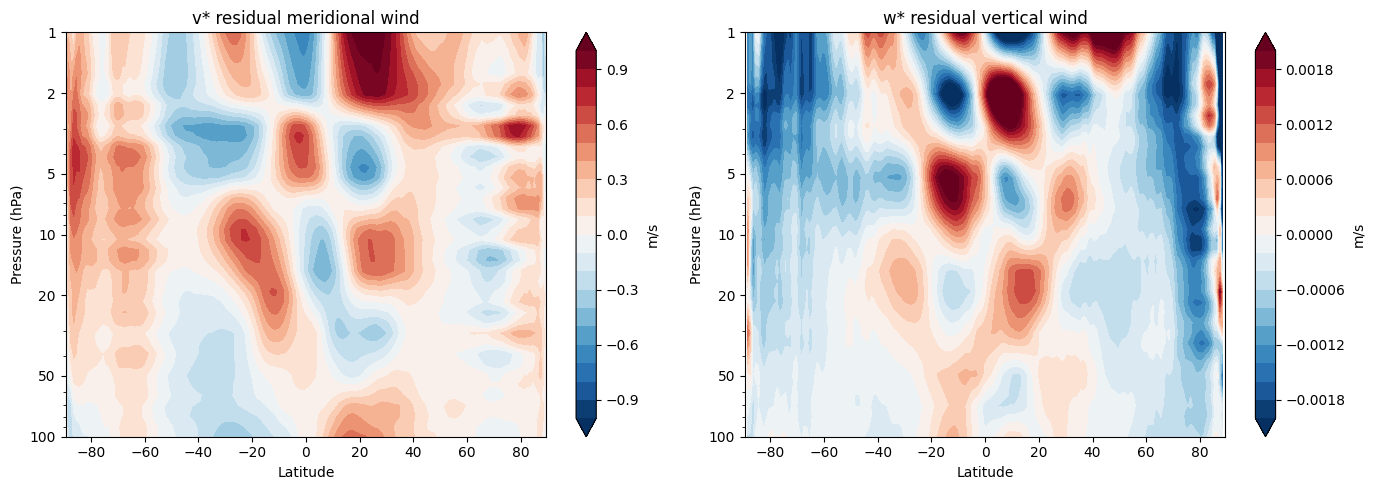

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ══════════════════════════════════════════════════════════════════════════════
# 0. Reload saved arrays (no NFS/zarr reads needed)
# ══════════════════════════════════════════════════════════════════════════════
save_dir = "./aide_residual_inputs/"
d = np.load(f"{save_dir}/aide_zonal_means_1997_2000.npz")
v_bar    = d['v_bar']      # (17, 180)
w_bar    = d['w_bar']
w_omega  = d['w_omega']
th_bar   = d['th_bar']
vth_eddy = d['vth_eddy']
T_bar    = d['T_bar']
ilev     = d['ilev']       # hPa, (17,)
lat      = d['lat']        # (180,), south->north

# ══════════════════════════════════════════════════════════════════════════════
# 1. Mask to stratosphere 1-100 hPa
# ══════════════════════════════════════════════════════════════════════════════
strat_mask = (ilev >= 1.0) & (ilev <= 100.0)
ilev     = ilev[strat_mask]
v_bar    = v_bar[strat_mask, :]
w_bar    = w_bar[strat_mask, :]
vth_eddy = vth_eddy[strat_mask, :]
th_bar   = th_bar[strat_mask, :]
print(f"After masking: {len(ilev)} levels, {ilev.min():.1f}-{ilev.max():.1f} hPa")

# ══════════════════════════════════════════════════════════════════════════════
# 2. Log-pressure height + flip to bottom->top (increasing z)
# ══════════════════════════════════════════════════════════════════════════════
H, p0 = 7000.0, 101325.0
z = -H * np.log(ilev * 100.0 / p0)

order = np.argsort(z)               # ensure strictly increasing z
z        = z[order]
ilev     = ilev[order]
v_bar    = v_bar[order, :]
w_bar    = w_bar[order, :]
vth_eddy = vth_eddy[order, :]
th_bar   = th_bar[order, :]
assert np.all(np.diff(z) > 0), "z not increasing"

# ══════════════════════════════════════════════════════════════════════════════
# 3. Regrid to UNIFORM log-pressure grid (second-order accurate derivatives)
# ══════════════════════════════════════════════════════════════════════════════
NZ = 40
z_uniform = np.linspace(z.min(), z.max(), NZ)

def regrid(field):                  # (nlev, nlat) -> (NZ, nlat)
    return np.vstack([np.interp(z_uniform, z, field[:, j])
                      for j in range(field.shape[1])]).T

v_bar    = regrid(v_bar)
w_bar    = regrid(w_bar)
th_bar   = regrid(th_bar)
vth_eddy = regrid(vth_eddy)

z    = z_uniform
ilev = p0/100.0 * np.exp(-z / H)    # hPa, for plotting
print(f"Regridded to {NZ} uniform log-p levels, {ilev.min():.2f}-{ilev.max():.1f} hPa")

# ══════════════════════════════════════════════════════════════════════════════
# 4. Constants & gradients
# ══════════════════════════════════════════════════════════════════════════════
r_earth = 6.371e6
lat_rad = np.deg2rad(lat)
cos_lat = np.cos(lat_rad)
sin_lat = np.sin(lat_rad)

th_bar_z    = np.gradient(th_bar,   z,       axis=0)
th_bar_zz   = np.gradient(th_bar_z, z,       axis=0)
th_bar_zphi = np.gradient(th_bar_z, lat_rad, axis=1)
dvth_dz     = np.gradient(vth_eddy, z,       axis=0)
dvth_dphi   = np.gradient(vth_eddy, lat_rad, axis=1)
print(f"d_theta/dz range: {th_bar_z.min():.4f} to {th_bar_z.max():.4f} K/m (expect >0)")

# ══════════════════════════════════════════════════════════════════════════════
# 5. Residual velocities (koval 2021 eqs 3 and 4: https://angeo.copernicus.org/articles/39/357/2021/)
# ══════════════════════════════════════════════════════════════════════════════
th_bar_z_safe = np.where(np.abs(th_bar_z) > 0, th_bar_z, np.nan)
cos_lat_safe  = np.where(np.abs(cos_lat) > 0.01, cos_lat, np.nan)

term1 = -vth_eddy / H
term2 =  dvth_dz
term3 = -vth_eddy / th_bar_z_safe * th_bar_zz
v_star = v_bar - (1.0 / th_bar_z_safe) * (term1 + term2 + term3)

termA = -sin_lat[None, :] * vth_eddy
termB =  cos_lat[None, :] * (dvth_dphi - vth_eddy / th_bar_z_safe * th_bar_zphi)
w_star = w_bar + (1.0 / (r_earth * cos_lat_safe[None, :])) * \
         (1.0 / th_bar_z_safe) * (termA + termB)

# ══════════════════════════════════════════════════════════════════════════════
# 6. Continuity check
# ══════════════════════════════════════════════════════════════════════════════
rho_z  = np.exp(-z / H)[:, None]
cosphi = np.cos(lat_rad)[None, :]
term_y = np.gradient(v_star * cosphi, r_earth * lat_rad, axis=1)
term_z = (1.0 / rho_z) * np.gradient(rho_z * w_star * cosphi, z, axis=0)
div    = np.nan_to_num(term_y + term_z)
scale  = np.nanmean(np.abs(term_z))

interior = np.abs(lat) < 60
polar    = np.abs(lat) > 60
print(f"continuity residual |lat|<60: "
      f"{np.nanmean(np.abs(div[:, interior]))/scale:.3f}")
print(f"continuity residual |lat|>60: "
      f"{np.nanmean(np.abs(div[:, polar]))/scale:.3f}")

# residual over 2-100 hPa only (exclude noisy top edge)
ok = ilev >= 2.0
print(f"continuity residual interior, 2-100 hPa: "
      f"{np.nanmean(np.abs(div[np.ix_(ok, interior)]))/scale:.3f}")

# per-level breakdown (interior)
print("\ndiv by level (interior |lat|<60):")
for k in range(len(ilev)):
    print(f"  {ilev[k]:7.2f} hPa: {np.nanmean(np.abs(div[k, interior]))/scale:.2f}")

print(f"\nv* range: {np.nanmin(v_star):.4f} to {np.nanmax(v_star):.4f} m/s")
print(f"w* range: {np.nanmin(w_star):.2e} to {np.nanmax(w_star):.2e} m/s")
print(f"w* tropics (|lat|<20) mean: {np.nanmean(w_star[:, np.abs(lat)<20]):.2e}")

# ══════════════════════════════════════════════════════════════════════════════
# 7. Plot
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cf1 = axes[0].contourf(lat, ilev, v_star, levels=np.linspace(-1, 1, 21),
                       cmap='RdBu_r', extend='both')
plt.colorbar(cf1, ax=axes[0], label='m/s')
axes[0].set_title('v* residual meridional wind')

cf2 = axes[1].contourf(lat, ilev, w_star, levels=np.linspace(-0.002, 0.002, 21),
                       cmap='RdBu_r', extend='both')
plt.colorbar(cf2, ax=axes[1], label='m/s')
axes[1].set_title('w* residual vertical wind')

for ax in axes:
    ax.set_yscale('log'); ax.invert_yaxis()
    ax.set_xlabel('Latitude'); ax.set_ylabel('Pressure (hPa)')
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_yticks([1, 2, 5, 10, 20, 50, 100])

plt.tight_layout()
plt.show()

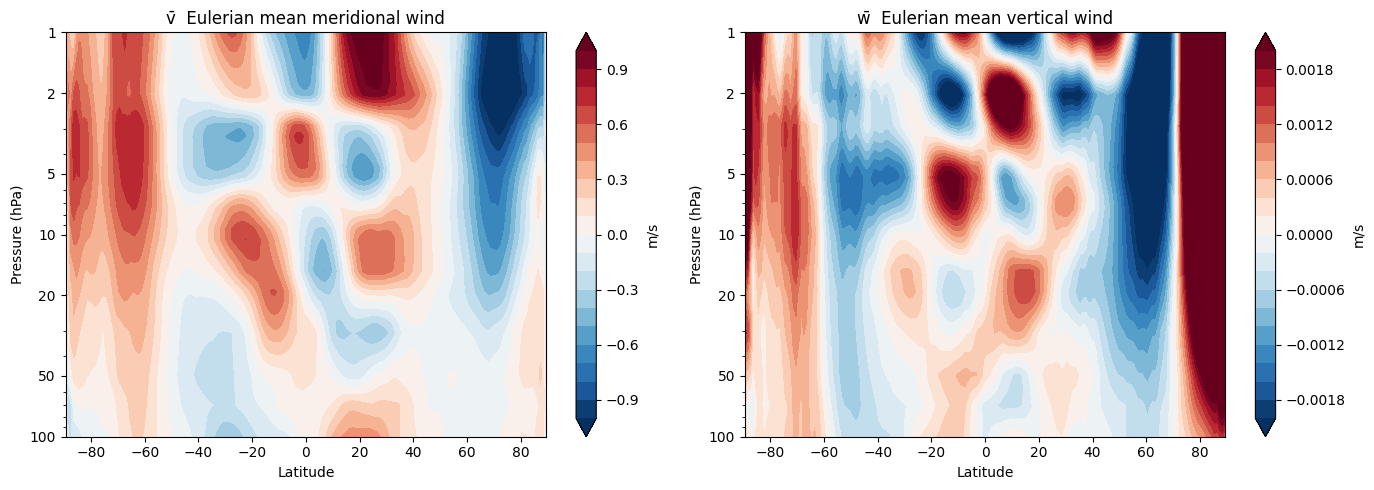

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# v_bar — Eulerian mean meridional wind
cf1 = axes[0].contourf(lat, ilev, v_bar,
                       levels=np.linspace(-1, 1, 21),
                       cmap='RdBu_r', extend='both')
plt.colorbar(cf1, ax=axes[0], label='m/s')
axes[0].set_title('v̄  Eulerian mean meridional wind')

# w_bar — geometric vertical wind (converted from omega)
cf2 = axes[1].contourf(lat, ilev, w_bar,
                       levels=np.linspace(-0.002, 0.002, 21),
                       cmap='RdBu_r', extend='both')
plt.colorbar(cf2, ax=axes[1], label='m/s')
axes[1].set_title('w̄  Eulerian mean vertical wind')

for ax in axes:
    ax.set_yscale('log'); ax.invert_yaxis()
    ax.set_xlabel('Latitude'); ax.set_ylabel('Pressure (hPa)')
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_yticks([1, 2, 5, 10, 20, 50, 100])

plt.tight_layout()
plt.show()

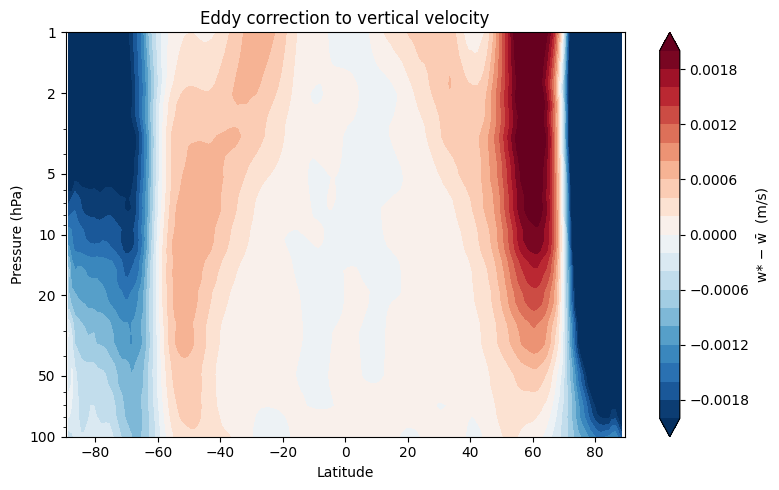

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

corr = w_star - w_bar   # eddy correction

fig, ax = plt.subplots(figsize=(8, 5))
cf = ax.contourf(lat, ilev, corr, levels=np.linspace(-0.002, 0.002, 21),
                 cmap='RdBu_r', extend='both')
plt.colorbar(cf, ax=ax, label='w* − w̄  (m/s)')
ax.set_yscale('log'); ax.invert_yaxis()
ax.set_xlabel('Latitude'); ax.set_ylabel('Pressure (hPa)')
ax.set_title('Eddy correction to vertical velocity')
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_yticks([1, 2, 5, 10, 20, 50, 100])
plt.tight_layout()
plt.show()